# Exploring the Dataset

This notebook introduces the electricity price and household load data used throughout the workshop. 

The data is synthetic (see `scripts/generate_data.py`) with daily and weekly patterns:
- **87,600 hours** of data (10 years, hourly resolution)
- **Prices** in €/kWh — vary by time of day and weekday/weekend
- **Loads** in kWh/h — household consumption patterns

Please note that there are no periodic patterns in the data besides the daily and weekly cycles. 

We have kept the data simple to focus on core concepts. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# The dataset contains primarily two timeseries: electricity prices and loads of the household: 
prices = np.load('../../03_data/prices.npy')
loads = np.load('../../03_data/loads.npy')
# Additionally, we have two timeseries that indicate the hour of the day and the day of the week for each timestep. 
hours_of_day = np.load('../../03_data/hours_of_day.npy') 
days_of_week = np.load('../../03_data/days_of_week.npy') # This information is only used for plotting.

print(f"Dataset: {len(prices):,} hours ({len(prices) / 8760:.0f} years)")
print(f"\nPrices (€/kWh):  min={prices.min():.3f}  max={prices.max():.3f}  mean={prices.mean():.3f}")
print(f"Loads (kWh/h):   min={loads.min():.3f}  max={loads.max():.3f}  mean={loads.mean():.3f}")

Dataset: 87,600 hours (10 years)

Prices (€/kWh):  min=0.050  max=0.629  mean=0.205
Loads (kWh/h):   min=0.100  max=2.742  mean=0.805


## One Week of Data

The cost of electricity is the product of price and load. So after one week, the total cost is the sum of price * load for each hour. This gives us a baseline cost to compare against when we optimize battery usage later on.

Let's visualize the first 168 hours (1 week) of the timeseries.

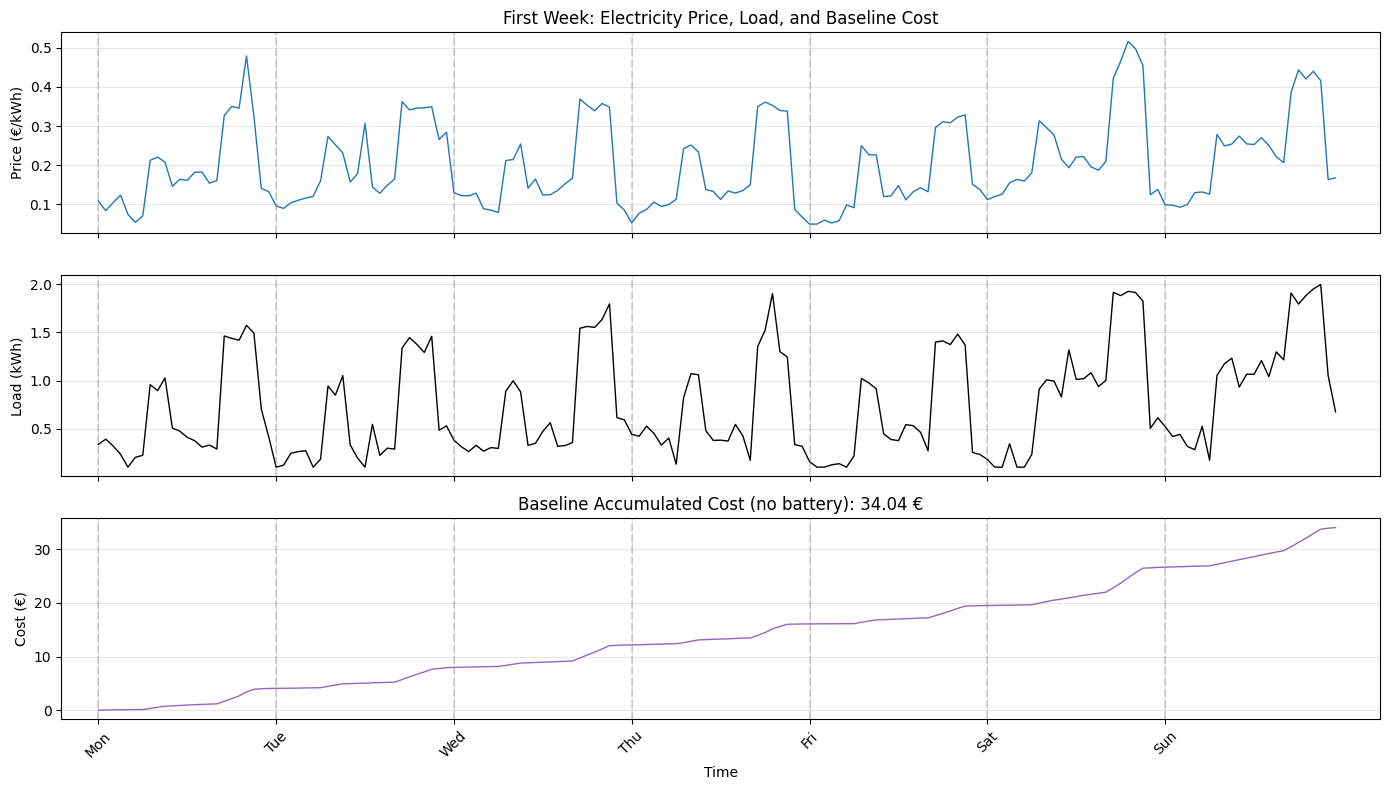

In [2]:
# Plot the first week (168 hours)
episode_length = 168
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
episode_prices = prices[:episode_length]  # slice first 168 values
episode_loads = loads[:episode_length]
hours = np.arange(episode_length)         # x-axis: [0, 1, 2, ..., 167]

# Create a 3-row subplot: price, load, and baseline cost
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Electricity price
ax1.plot(hours, episode_prices, 'tab:blue', linewidth=1)
ax1.set_ylabel('Price (€/kWh)')
ax1.set_title('First Week: Electricity Price, Load, and Baseline Cost')
ax1.grid(alpha=0.3)

# Household load
ax2.plot(hours, episode_loads, color='black', linewidth=1)
ax2.set_ylabel('Load (kWh)')
ax2.grid(alpha=0.3)

# Baseline cost = price * load each hour, accumulated over time
hourly_cost = episode_prices * episode_loads
accumulated_cost = np.cumsum(hourly_cost)  # running total
ax3.plot(hours, accumulated_cost, 'tab:purple', linewidth=1)
ax3.set_ylabel('Cost (€)')
ax3.set_title(f'Baseline Accumulated Cost (no battery): {accumulated_cost[-1]:.2f} €')
ax3.set_xlabel('Time')
ax3.grid(alpha=0.3)

# Place weekday labels at midnight boundaries (where hour_of_day == 0)
midnights = np.where(hours_of_day[:episode_length] == 0)[0]
ax3.set_xticks(midnights)
ax3.set_xticklabels([day_labels[days_of_week[i]] for i in midnights], rotation=45)
ax3.set_xlim(-5, episode_length + 5)

# Add vertical lines at midnight for better readability
for idx in midnights:
    for ax in [ax1, ax2, ax3]:
        ax.axvline(idx, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## One month of Data

Let's plot a longer stretch of the timeseries (1 month). 

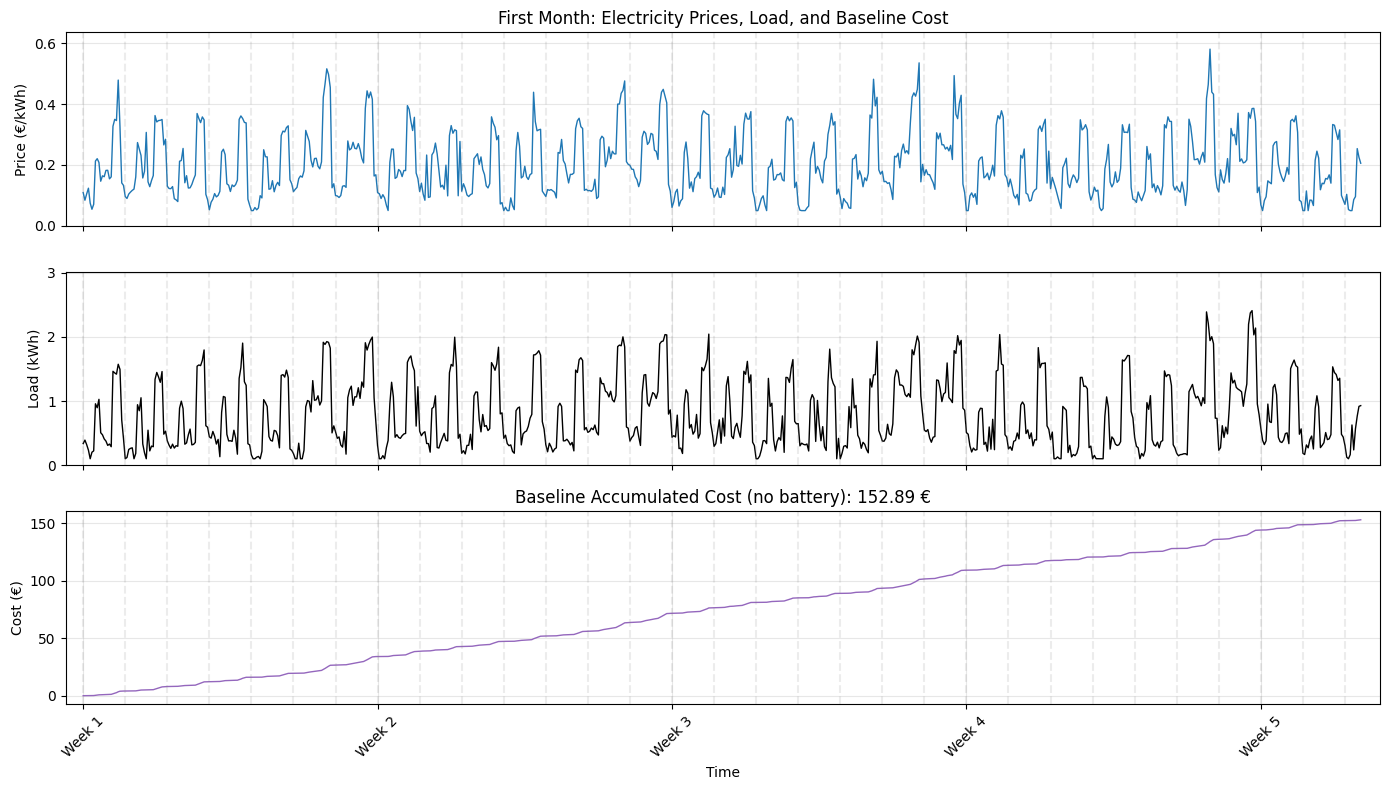

In [3]:
# Plot 1 month of the continuous timeseries
hours_to_plot = 730
prices_slice = prices[:hours_to_plot]
loads_slice = loads[:hours_to_plot]

# Create a 3-row subplot: price, load, and baseline cost
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Electricity price
ax1.plot(prices_slice, color='tab:blue', linewidth=1)
ax1.set_ylabel('Price (€/kWh)')
ax1.set_title('First Month: Electricity Prices, Load, and Baseline Cost')
ax1.set_ylim(0, prices.max() * 1.01)
ax1.grid(alpha=0.3)

# Household load
ax2.plot(loads_slice, color='black', linewidth=1)
ax2.set_ylabel('Load (kWh)')
ax2.set_ylim(0, loads.max() * 1.1)
ax2.grid(alpha=0.3)

# Baseline cost = price * load each hour, accumulated over time
hourly_cost = prices_slice * loads_slice
accumulated_cost = np.cumsum(hourly_cost)
ax3.plot(accumulated_cost, color='tab:purple', linewidth=1)
ax3.set_ylabel('Cost (€)')
ax3.set_title(f'Baseline Accumulated Cost (no battery): {accumulated_cost[-1]:.2f} €')
ax3.set_xlabel('Time')
ax3.grid(alpha=0.3)

# Show Monday labels only to avoid crowding
midnights = np.where(hours_of_day[:hours_to_plot] == 0)[0]
mondays = [i for i in midnights if days_of_week[i] == 0]
ax3.set_xticks(mondays)
ax3.set_xticklabels([f'Week {w+1}' for w in range(len(mondays))], rotation=45)
ax3.set_xlim(-10, hours_to_plot + 10)

# Add vertical lines at midnight for better readability
for idx in midnights:
    for ax in [ax1, ax2, ax3]:
        ax.axvline(idx, color='gray', linestyle='--', alpha=0.15)

plt.tight_layout()
plt.show()

## Simplifications in Our Model

Our toy model makes several simplifications to keep the workshop focused on RL concepts. In a more realistic scenario, you would encounter:

- **Seasonal patterns**: Real electricity prices and household loads vary by season and due to multiple weather-dependent and geopolitical factors. If you are interested in this, take a look for example at the Smard dataset in `03_data/alternative_datasets/smard/explore_smard_data.ipynb`. Our data only has daily and weekly cycles.
- **Round-trip efficiency losses**: Real batteries lose energy per charge/discharge cycle. We assume 100% efficiency for simplicity.
- **Price uncertainty**: Real-time electricity prices can be far more volatile than our smooth synthetic data, with occasional negative prices (when renewable generation exceeds demand) and extreme spikes. Our data has mild spikes but no negative prices.
- **Battery degradation**: We model this optionally (more on that later on), but real degradation is sginificantly more complex and depends on temperature, depth of discharge, charge rate, aging and so on. We will use a much simpler degradation model.
- **Grid feed-in**: We assume the household cannot sell electricity back to the grid. In some markets, feed-in tariffs allow selling surplus solar/battery energy, which changes the optimal strategy significantly.
- **Self-discharge**: Real batteries slowly lose charge over time even when idle. We ignore this.
- ...